# V9: 날씨 데이터를 결합한 참여율(Ratio) 예측 고도화

이 노트북은 V7의 '참여율(Ratio)' 예측 전략에 외부 날씨 데이터를 결합하여 성능을 향상시키는 것을 목표로 합니다.
V8에서 발생했던 테스트 데이터 날씨 부재 문제를 해결하기 위해 `weatherTest.csv`를 사용합니다.

## 주요 전략
1. **데이터 통합**: Train/Test 데이터에 각각의 날씨 데이터 결합
2. **날씨 피처 생성**: 강수량 결측치 처리, 비온날 여부(Rainy), 불쾌지수 등 추가
3. **참여율 기반 예측**: 식사가능자수 대비 실제 식사인원 비율 예측 (XGBRegressor)
4. **시각화 분석**: 날씨가 식수 인원에 미치는 영향 분석


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import warnings
from korean_font import set_korean_font

# 한글 폰트 설정
set_korean_font()
warnings.filterwarnings('ignore')
plt.rcParams['axes.unicode_minus'] = False


한글 폰트 설정: Malgun Gothic (c:/Windows/Fonts/malgun.ttf)


In [7]:
# 1. 데이터 로드
train = pd.read_csv('data/train_median.csv')
test = pd.read_csv('data/test.csv')
submission = pd.read_csv('data/sample_submission.csv')
weather_train = pd.read_csv('data/weather.csv')
weather_test = pd.read_csv('data/weatherTest.csv')

# 2. 날씨 데이터 전처리 및 통합
weather = pd.concat([weather_train, weather_test], axis=0)
weather = weather[['일시', '기온', '강수량', '풍속', '습도']]
weather['일시'] = pd.to_datetime(weather['일시'])

# 3. 메인 데이터 날짜 변환 및 결합
train['일자'] = pd.to_datetime(train['일자'])
test['일자'] = pd.to_datetime(test['일자'])

train = pd.merge(train, weather, left_on='일자', right_on='일시', how='left')
test = pd.merge(test, weather, left_on='일자', right_on='일시', how='left')

train.drop(['일시'], axis=1, inplace=True)
test.drop(['일시'], axis=1, inplace=True)

print("데이터 결합 완료:", train.shape, test.shape)


데이터 결합 완료: (1220, 16) (50, 14)


In [8]:
# 4. 피처 엔지니어링
for df in [train, test]:
    # 기본 날짜 피처
    df['년'] = df['일자'].dt.year
    df['월'] = df['일자'].dt.month
    df['일'] = df['일자'].dt.day
    df['요일'] = df['일자'].dt.weekday
    
    # 식사가능자수
    df['식사가능자수'] = df['본사정원수'] - (df['본사휴가자수'] + df['본사출장자수'] + df['현본사소속재택근무자수'])
    
    # 날씨 피처 보정
    df['강수량'] = df['강수량'].fillna(0)
    df['비온날'] = (df['강수량'] > 0).astype(int)
    
    # 불쾌지수 (Discomfort Index) 계산 예시
    # DI = 0.81 * 기온 + 0.01 * 습도 * (0.99 * 기온 - 14.3) + 46.3
    df['불쾌지수'] = 0.81 * df['기온'] + 0.01 * df['습도'] * (0.99 * df['기온'] - 14.3) + 46.3

# Target: 참여율 생성
train['중식참여율'] = train['중식계'] / train['식사가능자수']
train['석식참여율'] = train['석식계'] / train['식사가능자수']

train.head()


,일자,요일,본사정원수,본사휴가자수,본사출장자수,본사시간외근무명령서승인건수,현본사소속재택근무자수,조식메뉴,중식메뉴,석식메뉴,...,풍속,습도,년,월,일,식사가능자수,비온날,불쾌지수,중식참여율,석식참여율
0,2016-02-01,0,2601,50,150,238,0.0,모닝롤/찐빵 우유/두유/주스 계란후라이 호두죽/쌀밥 (쌀:국내산) 된장찌개 쥐...,"쌀밥/잡곡밥 (쌀,현미흑미:국내산) 오징어찌개 쇠불고기 (쇠고기:호주산) 계란찜 ...","쌀밥/잡곡밥 (쌀,현미흑미:국내산) 육개장 자반고등어구이 두부조림 건파래무침 ...",...,1.3,43.9,2016,2,1,2401.0,0,39.275534,0.432736,0.137859
1,2016-02-02,1,2601,50,173,319,0.0,모닝롤/단호박샌드 우유/두유/주스 계란후라이 팥죽/쌀밥 (쌀:국내산) 호박젓국찌...,"쌀밥/잡곡밥 (쌀,현미흑미:국내산) 김치찌개 가자미튀김 모둠소세지구이 마늘쫑무...","콩나물밥*양념장 (쌀,현미흑미:국내산) 어묵국 유산슬 (쇠고기:호주산) 아삭고추무...",...,0.8,47.5,2016,2,2,2378.0,0,36.562925,0.364592,0.235492
2,2016-02-03,2,2601,56,180,111,0.0,모닝롤/베이글 우유/두유/주스 계란후라이 표고버섯죽/쌀밥 (쌀:국내산) 콩나물국...,"카레덮밥 (쌀,현미흑미:국내산) 팽이장국 치킨핑거 (닭고기:국내산) 쫄면야채무침 ...","쌀밥/잡곡밥 (쌀,현미흑미:국내산) 청국장찌개 황태양념구이 (황태:러시아산) 고기...",...,0.6,57.1,2016,2,3,2365.0,0,35.796707,0.430021,0.242283
3,2016-02-04,3,2601,104,220,355,0.0,"모닝롤/토마토샌드 우유/두유/주스 계란후라이 닭죽/쌀밥 (쌀,닭:국내산) 근대국...","쌀밥/잡곡밥 (쌀,현미흑미:국내산) 쇠고기무국 주꾸미볶음 부추전 시금치나물 ...","미니김밥*겨자장 (쌀,현미흑미:국내산) 우동 멕시칸샐러드 군고구마 무피클 포...",...,0.7,53.4,2016,2,4,2277.0,0,38.396068,0.429513,0.230567
4,2016-02-05,4,2601,278,181,34,0.0,모닝롤/와플 우유/두유/주스 계란후라이 쇠고기죽/쌀밥 (쌀:국내산) 재첩국 방...,"쌀밥/잡곡밥 (쌀,현미흑미:국내산) 떡국 돈육씨앗강정 (돼지고기:국내산) 우엉잡채...","쌀밥/잡곡밥 (쌀,현미흑미:국내산) 차돌박이찌개 (쇠고기:호주산) 닭갈비 (닭고기:...",...,1.0,44.4,2016,2,5,2142.0,0,41.575228,0.431839,0.154062


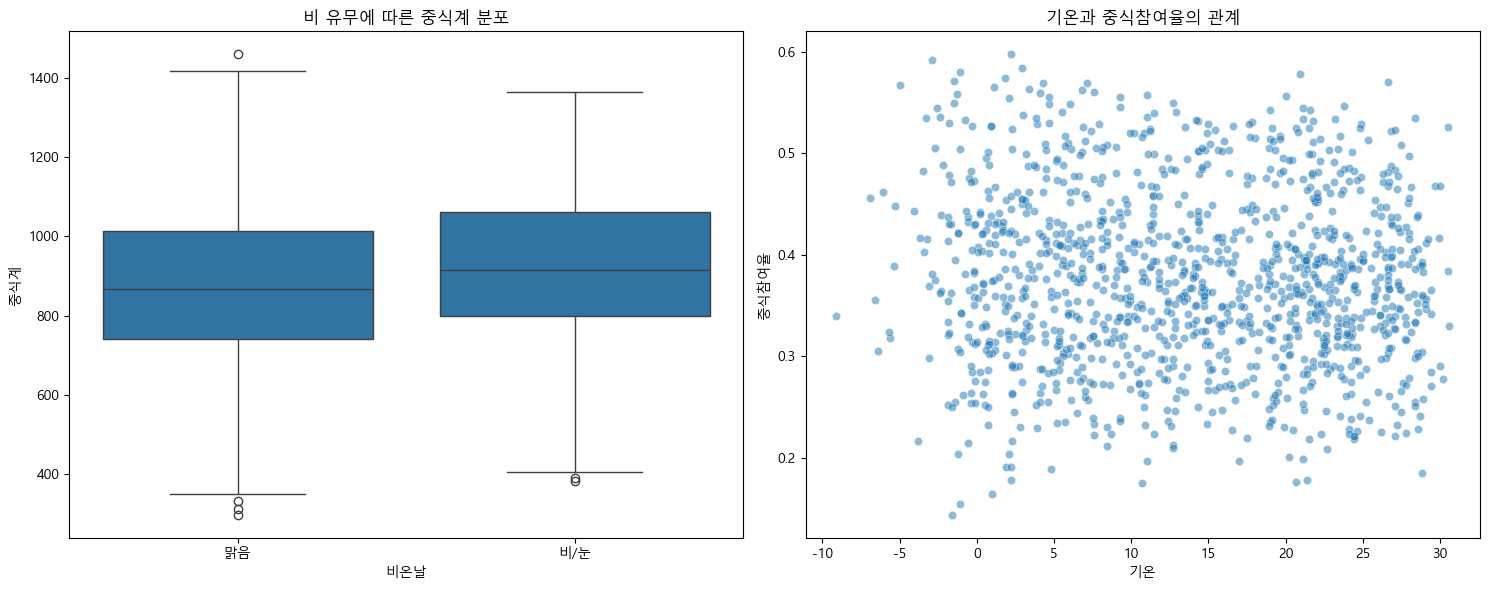

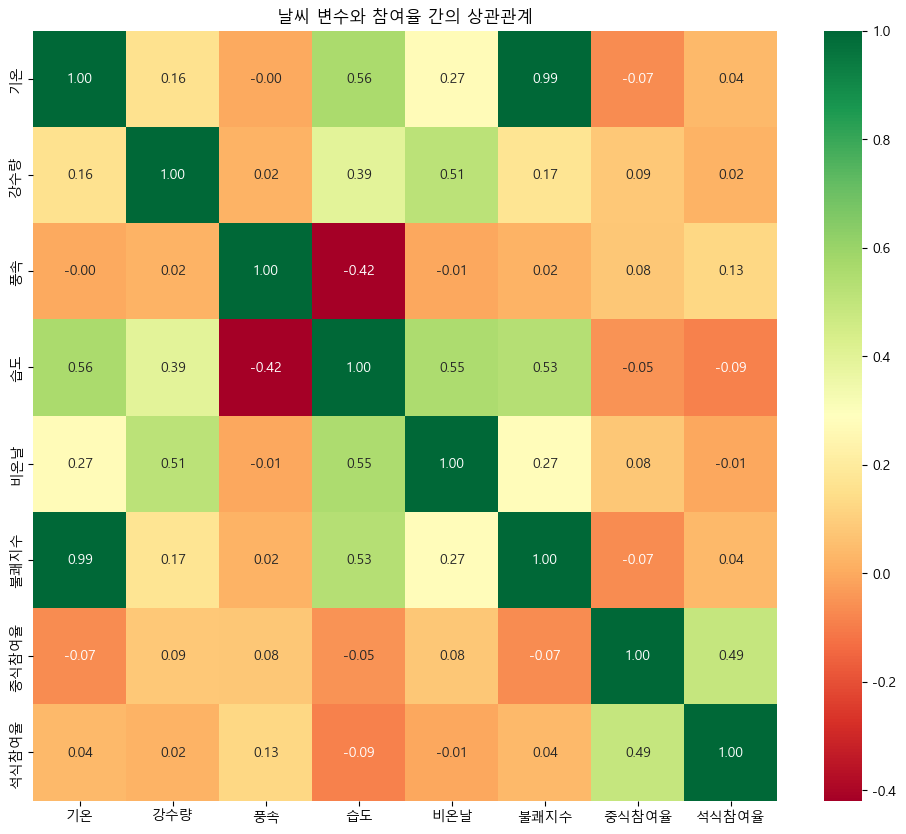

In [9]:
# 5. 시각화: 날씨와 식수 인원의 관계
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# 비온 날 vs 안 온 날 중식계 비교
sns.boxplot(data=train, x='비온날', y='중식계', ax=ax[0])
ax[0].set_title('비 유무에 따른 중식계 분포')
ax[0].set_xticklabels(['맑음', '비/눈'])

# 기온과 중식참여율 산점도
sns.scatterplot(data=train, x='기온', y='중식참여율', alpha=0.5, ax=ax[1])
ax[1].set_title('기온과 중식참여율의 관계')

plt.tight_layout()
plt.show()

# 상관관계 확인
plt.figure(figsize=(12, 10))
weather_cols = ['기온', '강수량', '풍속', '습도', '비온날', '불쾌지수', '중식참여율', '석식참여율']
sns.heatmap(train[weather_cols].corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('날씨 변수와 참여율 간의 상관관계')
plt.show()


In [10]:
# 6. 모델링
features = ['월', '요일', '식사가능자수', '본사출장자수', '본사시간외근무명령서승인건수', 
            '기온', '강수량', '습도', '비온날', '불쾌지수']

x_train = train[features]
y_lunch = train['중식참여율']
y_dinner = train['석식참여율']
x_test = test[features]

# XGBRegressor 파라미터 튜닝 (기본값보다 조금 더 보수적으로 설정)
xgb_params = {
    'n_estimators': 2000,
    'learning_rate': 0.02,
    'max_depth': 6,
    'colsample_bytree': 0.8,
    'subsample': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1,
    'random_state': 42,
    'n_jobs': -1
}

model_lunch = XGBRegressor(**xgb_params)
model_lunch.fit(x_train, y_lunch)

model_dinner = XGBRegressor(**xgb_params)
model_dinner.fit(x_train, y_dinner)

print("모델 학습 및 예측 준비 완료")


모델 학습 및 예측 준비 완료


제출 파일 저장 완료: submission/submission_v9.csv


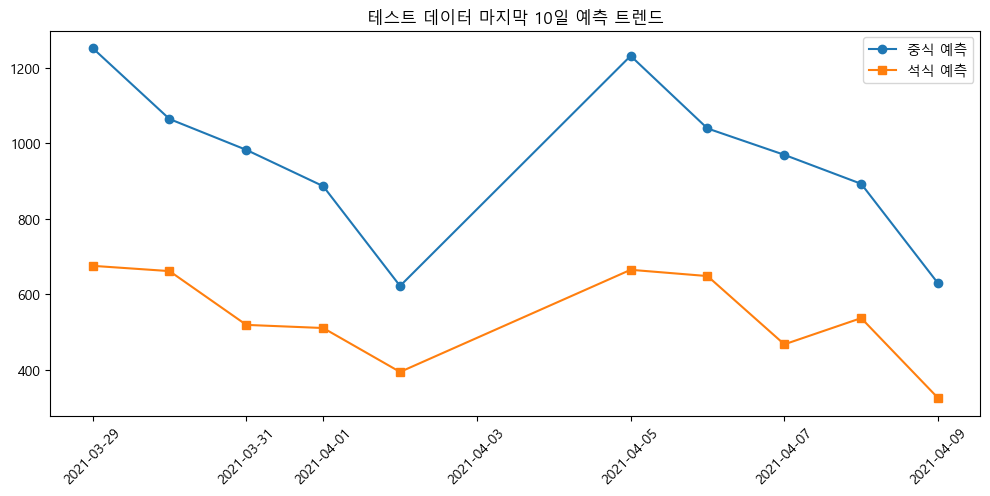

In [11]:
# 7. 예측 및 결과 저장
pred_lunch_ratio = model_lunch.predict(x_test)
pred_dinner_ratio = model_dinner.predict(x_test)

# 실제 인원수로 복원
test['pred_lunch'] = pred_lunch_ratio * test['식사가능자수']
test['pred_dinner'] = pred_dinner_ratio * test['식사가능자수']

submission['중식계'] = test['pred_lunch']
submission['석식계'] = test['pred_dinner']

submission.to_csv('submission/submission_v9.csv', index=False)
print("제출 파일 저장 완료: submission/submission_v9.csv")

# 예측 결과 시각화 (마지막 10일)
plt.figure(figsize=(12, 5))
plt.plot(test['일자'][-10:], test['pred_lunch'][-10:], marker='o', label='중식 예측')
plt.plot(test['일자'][-10:], test['pred_dinner'][-10:], marker='s', label='석식 예측')
plt.title('테스트 데이터 마지막 10일 예측 트렌드')
plt.legend()
plt.xticks(rotation=45)
plt.show()
